# 🎯 Thực nghiệm v4: Direct multi-horizon + Đa seed + Thống kê đầy đủ
Bản hoàn thiện cho bài báo — khắc phục 2 điểm yếu của v3 và chuẩn hoá đánh giá đa hạt-giống.

### Hai nâng cấp cốt lõi
1. **Sửa hiện tượng "nổ" ở tầm nhìn dài (h=28)** bằng **dự báo đa-bước trực tiếp (direct multi-horizon)**:
   mô hình xuất **thẳng vector H bước** thay vì đệ quy 1-bước ⇒ **không dồn lỗi**. (v3 dùng đệ quy nên
   TCN/GRU/Auto sụp R² về 0.2–0.5 ở h=28; direct đưa R² h=28 lên ~0.9.)
2. **Đa seed đầy đủ cho MỌI mô hình học sâu & ensemble**: chạy nhiều hạt giống, báo cáo **trung bình ±
   độ lệch chuẩn**, **kiểm định Wilcoxon/t-test** so với baseline, và tính **Diebold–Mariano + MCS trên
   dự báo trung bình-qua-seed** (giảm nhiễu ngẫu nhiên khởi tạo).

### Thiết kế
- Mọi kiến trúc (TCN, N-BEATS, GRU, …) dùng **chung pipeline**: log-transform → (tuỳ chọn) sai phân →
  cửa sổ trượt → **direct multi-horizon** → rolling ngoài mẫu.
- Baseline chuẩn hoá: ARIMA, RW-drift, **⟨arch⟩(direct)** (không phân rã), ARIMA-LSTM cổ điển.
- Ensemble sau phân rã: **DEC-⟨arch⟩**, **DEC-Auto** (chọn theo val mỗi thành phần), **DEC-EnsAvg/EnsWgt**.
- **Lưu kết quả từng seed ra Drive ngay khi chạy** ⇒ an toàn nếu Colab ngắt kết nối.


## 0. Cài đặt & mount

In [1]:
!pip -q install pmdarima arch 2>/dev/null || echo "thiếu pmdarima/arch -> fallback"
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 66.7 MB/s eta 0:00:00
Mounted at /content/drive


## 1. Cấu hình

In [2]:
import os
CONFIG=dict(
    DATA_DIR='/content/drive/MyDrive/NCS/Hoa/paper14/1-data/', FILE_NAME=None,
    DATE_COL='Date', TARGET='Close', OHLCV_COLS=['Open','High','Low','Close','Volume'],
    SEASONAL_PERIOD=30, HORIZONS=[1,7,14,28], DECOMPOSITIONS=['STL','RobustSTL'], TEST_SIZE=365,
    DEEP_MODELS=['TCN','NBEATS','GRU'],          # chọn từ: MLP,LSTM,GRU,TCN,NBEATS,TRANSFORMER
    LOOKBACK=60, USE_OHLCV_FEATURES=True, DIFFERENCE_NONSTATIONARY=True,
    UNITS=64, EPOCHS=100, BATCH=32, LR=1e-3, PATIENCE=12,
    ADD_ARIMA=True, ADD_RW=True, ADD_CLASSICAL_ARIMA_LSTM=True,
    RUN_DEC_AUTO=True, RUN_DEC_ENSEMBLE=True,
    # ---- ĐA SEED ----
    SEEDS=[42,43,44,45,46,47,48,49,50,51],        # 10 seed: Wilcoxon đạt được p<0.05
    # ---- thống kê ----
    RUN_DM=True, RUN_MCS=True, MCS_SIZE=0.10,
    OUT_DIR='/content/drive/MyDrive/NCS/Hoa/paper14/3-results_v4/',
)
QUICK_MODE=False
if QUICK_MODE: CONFIG.update(TEST_SIZE=120,EPOCHS=15,DEEP_MODELS=['TCN','GRU'],SEEDS=[42,43])
os.makedirs(CONFIG['OUT_DIR'],exist_ok=True); MAX_H=max(CONFIG['HORIZONS']); CONFIG

{'DATA_DIR': '/content/drive/MyDrive/NCS/Hoa/paper14/1-data/',
 'FILE_NAME': None,
 'DATE_COL': 'Date',
 'TARGET': 'Close',
 'OHLCV_COLS': ['Open', 'High', 'Low', 'Close', 'Volume'],
 'SEASONAL_PERIOD': 30,
 'HORIZONS': [1, 7, 14, 28],
 'DECOMPOSITIONS': ['STL', 'RobustSTL'],
 'TEST_SIZE': 365,
 'DEEP_MODELS': ['TCN', 'NBEATS', 'GRU'],
 'LOOKBACK': 60,
 'USE_OHLCV_FEATURES': True,
 'DIFFERENCE_NONSTATIONARY': True,
 'UNITS': 64,
 'EPOCHS': 100,
 'BATCH': 32,
 'LR': 0.001,
 'PATIENCE': 12,
 'ADD_ARIMA': True,
 'ADD_RW': True,
 'ADD_CLASSICAL_ARIMA_LSTM': True,
 'RUN_DEC_AUTO': True,
 'RUN_DEC_ENSEMBLE': True,
 'SEEDS': [42, 43, 44, 45, 46, 47, 48, 49, 50, 51],
 'RUN_DM': True,
 'RUN_MCS': True,
 'MCS_SIZE': 0.1,
 'OUT_DIR': '/content/drive/MyDrive/NCS/Hoa/paper14/3-results_v4/'}

In [3]:
import numpy as np, pandas as pd, random, warnings, glob, time, json
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
print('TF',tf.__version__); plt.rcParams['figure.figsize']=(12,4); plt.rcParams['figure.dpi']=110

TF 2.20.0


## 2. Nạp & tiền xử lý (log-transform)

In [4]:
def find_data_file(cfg):
    if cfg['FILE_NAME']: return os.path.join(cfg['DATA_DIR'],cfg['FILE_NAME'])
    csvs=sorted(glob.glob(os.path.join(cfg['DATA_DIR'],'*.csv')))
    if not csvs: raise FileNotFoundError(cfg['DATA_DIR'])
    btc=[c for c in csvs if 'btc' in os.path.basename(c).lower()]; return btc[0] if btc else csvs[0]
path=find_data_file(CONFIG); print('Đọc:',path)
raw=pd.read_csv(path); raw[CONFIG['DATE_COL']]=pd.to_datetime(raw[CONFIG['DATE_COL']],utc=True,errors='coerce')
raw=(raw.dropna(subset=[CONFIG['DATE_COL']]).sort_values(CONFIG['DATE_COL']).drop_duplicates(CONFIG['DATE_COL']).set_index(CONFIG['DATE_COL']))
df=raw[[c for c in CONFIG['OHLCV_COLS'] if c in raw.columns]].apply(pd.to_numeric,errors='coerce')
df=df[df[CONFIG['TARGET']]>0].interpolate(limit_direction='both')
feat=pd.DataFrame(index=df.index)
for c in ['Open','High','Low','Close']:
    if c in df: feat['log_'+c.lower()]=np.log(df[c].clip(lower=1e-8))
if 'Volume' in df: feat['log_volume']=np.log1p(df['Volume'].clip(lower=0))
y_log=pd.Series(np.log(df[CONFIG['TARGET']].values.astype(float)),index=df.index,name='log_close')
price=df[CONFIG['TARGET']].astype(float); print('N=',len(df))

Đọc: /content/drive/MyDrive/NCS/Hoa/paper14/1-data/BTC_all (6).csv
N= 3921


## 3. Phân rã & chia dữ liệu

In [5]:
from statsmodels.tsa.seasonal import STL
def decompose(s,period,robust):
    r=STL(s,period=period,robust=robust).fit()
    return pd.DataFrame({'trend':r.trend,'seasonal':r.seasonal,'resid':r.resid},index=s.index)
DECOMP={n:decompose(y_log,CONFIG['SEASONAL_PERIOD'],n=='RobustSTL') for n in CONFIG['DECOMPOSITIONS']}
for n in DECOMP: print(n,'recon',f"{np.max(np.abs(DECOMP[n].sum(1).values-y_log.values)):.1e}")
N=len(y_log); N_TEST=CONFIG['TEST_SIZE']; N_TRAIN=N-N_TEST
price_arr=price.values; log_arr=y_log.values
EXOG=feat[[c for c in feat.columns if c!='log_close']].copy() if CONFIG['USE_OHLCV_FEATURES'] else None
print(f'N={N} Train={N_TRAIN} Test={N_TEST}')

STL recon 1.8e-15
RobustSTL recon 1.8e-15
N=3921 Train=3556 Test=365


## 4. 🆕 Kiến trúc & engine **direct multi-horizon**
Mỗi kiến trúc nhận cửa sổ `(LOOKBACK, n_feat)` và **xuất thẳng H giá trị** (dự báo 1..H bước). Với chuỗi
phi dừng dùng **sai phân**: mục tiêu là `base[t+h]-base[t]` (thay đổi h-bước), rồi tái tạo mức
`= base[gốc] + dự_báo`. Không đệ quy ⇒ không dồn lỗi ở tầm nhìn dài.

In [6]:
def build_model(kind,lookback,n_feat,out_dim,cfg):
    kind=kind.upper(); inp=Input((lookback,n_feat)); U=cfg['UNITS']
    if kind=='MLP':
        x=layers.Flatten()(inp);x=layers.Dense(U,activation='relu')(x);x=layers.Dense(U,activation='relu')(x)
    elif kind in ('LSTM','GRU'):
        L=layers.LSTM if kind=='LSTM' else layers.GRU; x=L(U,return_sequences=True)(inp);x=L(U)(x)
    elif kind=='TCN':
        x=inp
        for d in (1,2,4,8): x=layers.Conv1D(U,3,padding='causal',dilation_rate=d,activation='relu')(x)
        x=layers.Lambda(lambda t:t[:,-1,:])(x)
    elif kind=='TRANSFORMER':
        x=layers.Dense(U)(inp);pos=tf.range(0,lookback);x=x+layers.Embedding(lookback,U)(pos)
        a=layers.MultiHeadAttention(4,max(U//4,8))(x,x);x=layers.LayerNormalization()(x+a)
        f=layers.Dense(U,activation='relu')(x);f=layers.Dense(U)(f);x=layers.LayerNormalization()(x+f)
        x=layers.GlobalAveragePooling1D()(x)
    elif kind=='NBEATS':
        x0=layers.Flatten()(inp);in_dim=lookback*n_feat;back=x0;fc=None
        for _ in range(3):
            h=layers.Dense(U,activation='relu')(back);h=layers.Dense(U,activation='relu')(h)
            b=layers.Dense(in_dim)(h);f=layers.Dense(out_dim)(h)
            back=layers.Subtract()([back,b]);fc=f if fc is None else layers.Add()([fc,f])
        m=Model(inp,fc);m.compile(Adam(cfg['LR']),'mse');return m
    else: raise ValueError(kind)
    out=layers.Dense(out_dim)(x); m=Model(inp,out);m.compile(Adam(cfg['LR']),'mse');return m

def deep_direct(target,exog_df,n_train,cfg,horizons,kind='TCN',seed=42,difference=True):
    tf.keras.backend.clear_session();np.random.seed(seed);tf.random.set_seed(seed);random.seed(seed)
    base=np.asarray(target,float);Nt=len(base);H=max(horizons);use_exog=exog_df is not None
    if difference:
        work=np.diff(base);off=1;exw=np.diff(exog_df.values.astype(float),axis=0) if use_exog else None;ntw=n_train-1
    else:
        work=base.copy();off=0;exw=exog_df.values.astype(float) if use_exog else None;ntw=n_train
    F=np.hstack([work.reshape(-1,1),exw]) if exw is not None else work.reshape(-1,1)
    nf=F.shape[1];lb=cfg['LOOKBACK']
    mu=F[:ntw].mean(0);sd=F[:ntw].std(0);sd[sd==0]=1;Fs=(F-mu)/sd
    tgt=lambda i:np.array([base[i+h]-base[i] if difference else base[i+h] for h in range(1,H+1)])
    Xtr=[];Ytr=[]
    for i in range(lb-1+off,n_train-H):
        p=i-off;Xtr.append(Fs[p-lb+1:p+1]);Ytr.append(tgt(i))
    Xtr=np.array(Xtr,'float32');Ytr=np.array(Ytr,'float32')
    tmu=Ytr.mean(0);tsd=Ytr.std(0);tsd[tsd==0]=1;Ys=(Ytr-tmu)/tsd
    m=build_model(kind,lb,nf,H,cfg)
    es=EarlyStopping(monitor='val_loss',patience=cfg['PATIENCE'],restore_best_weights=True)
    hist=m.fit(Xtr,Ys,epochs=cfg['EPOCHS'],batch_size=cfg['BATCH'],validation_split=0.1,callbacks=[es],verbose=0)
    val=float(np.sqrt(min(hist.history['val_loss'])))
    origins=np.arange(n_train-1,Nt-1);Wp=origins-off
    W=np.stack([Fs[p-lb+1:p+1] for p in Wp]).astype('float32')
    yh=m(W,training=False).numpy()*tsd+tmu
    P={h:[] for h in horizons};I={h:[] for h in horizons}
    for k,i in enumerate(origins):
        for h in horizons:
            if i+h<=Nt-1:
                v=base[i]+yh[k,h-1] if difference else yh[k,h-1]
                P[h].append(v);I[h].append(i+h)
    return {h:np.array(P[h]) for h in horizons},{h:np.array(I[h]) for h in horizons},val

## 5. Baseline cổ điển: ARIMA, RW-drift (tất định — chạy 1 lần)

In [7]:
from statsmodels.tsa.arima.model import ARIMA
def select_arima_order(train):
    try:
        import pmdarima as pm
        return pm.auto_arima(train,seasonal=False,stepwise=True,suppress_warnings=True,error_action='ignore',max_p=3,max_q=3,max_d=2).order
    except Exception:
        best,ba=(1,1,1),np.inf
        for p in range(4):
            for d in range(3):
                for q in range(4):
                    try:
                        a=ARIMA(train,order=(p,d,q)).fit().aic
                        if a<ba: ba,best=a,(p,d,q)
                    except: pass
        return best
def arima_roll(full,n_train,order,horizons):
    v=np.asarray(full,float);mh=max(horizons)
    try:
        res=ARIMA(v[:n_train],order=order).fit()
    except Exception as e:
        print('  [ARIMA fit lỗi',order,'-> fallback RW-drift]',str(e)[:60]); return rw(full,n_train,horizons)
    P={h:[] for h in horizons};I={h:[] for h in horizons};Nt=len(v)
    for i in range(n_train-1,Nt-1):
        try: fc=np.asarray(res.forecast(steps=mh))
        except Exception:
            dr=np.mean(np.diff(v[:i+1])); fc=np.array([v[i]+ (k+1)*dr for k in range(mh)])
        for h in horizons:
            if i+h<=Nt-1: P[h].append(fc[h-1]);I[h].append(i+h)
        try: res=res.append([v[i+1]],refit=False)
        except Exception: pass
    return {h:np.array(P[h]) for h in horizons},{h:np.array(I[h]) for h in horizons}
def rw(full,n_train,horizons):
    v=np.asarray(full,float);dr=np.mean(np.diff(v[:n_train]));Nt=len(v)
    P={h:[] for h in horizons};I={h:[] for h in horizons}
    for i in range(n_train-1,Nt-1):
        for h in horizons:
            if i+h<=Nt-1: P[h].append(v[i]+h*dr);I[h].append(i+h)
    return {h:np.array(P[h]) for h in horizons},{h:np.array(I[h]) for h in horizons}
HZ=CONFIG['HORIZONS']
DET={}   # tất định: name -> (logP,I)
if CONFIG['ADD_ARIMA']:
    oB=select_arima_order(log_arr[:N_TRAIN]); print('ARIMA',oB); DET['ARIMA']=arima_roll(log_arr,N_TRAIN,oB,HZ)
if CONFIG['ADD_RW']: DET['RW-drift']=rw(log_arr,N_TRAIN,HZ)
ARIMA_TREND={}
if CONFIG['ADD_CLASSICAL_ARIMA_LSTM']:
    for d in CONFIG['DECOMPOSITIONS']:
        oT=select_arima_order(DECOMP[d]['trend'].values[:N_TRAIN]); ARIMA_TREND[d]=arima_roll(DECOMP[d]['trend'].values,N_TRAIN,oT,HZ)
    print('ARIMA-trend xong')

ARIMA (0, 1, 0)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


ARIMA-trend xong


## 6. Chỉ số & kiểm định

In [8]:
def metrics_full(y_true,y_pred,y_org=None):
    y_true=np.asarray(y_true,float);y_pred=np.asarray(y_pred,float);e=y_true-y_pred
    r=dict(RMSE=np.sqrt(np.mean(e**2)),MAE=np.mean(np.abs(e)),MAPE=np.mean(np.abs(e/y_true))*100,
           sMAPE=np.mean(2*np.abs(e)/(np.abs(y_true)+np.abs(y_pred)+1e-12))*100)
    sst=np.sum((y_true-np.mean(y_true))**2);r['R2']=1-np.sum(e**2)/sst if sst>0 else np.nan
    if y_org is not None:
        y_org=np.asarray(y_org,float);den=np.sqrt(np.mean((y_org-y_true)**2))
        r['TheilU']=np.sqrt(np.mean((y_pred-y_true)**2))/den if den>0 else np.nan
        r['DA']=np.mean(np.sign(y_pred-y_org)==np.sign(y_true-y_org))*100
    return r
def dm_test(e1,e2,h=1,loss='MSE'):
    e1=np.asarray(e1,float);e2=np.asarray(e2,float)
    d=(e1**2-e2**2) if loss=='MSE' else (np.abs(e1)-np.abs(e2))
    T=len(d);db=d.mean();g0=np.mean((d-db)**2)
    gs=sum(np.mean((d[k:]-db)*(d[:-k]-db)) for k in range(1,h));var=(g0+2*gs)/T
    if var<=0 or T<3: return np.nan,np.nan
    DM=db/np.sqrt(var)*np.sqrt((T+1-2*h+h*(h-1)/T)/T);return DM,2*stats.t.cdf(-abs(DM),df=T-1)
def price_pred(logP,h): return np.exp(logP[h])

## 7. 🆕 Chạy ĐA SEED (lưu từng seed ra Drive)
Với mỗi seed: dự báo trực tiếp (baseline), DEC-⟨arch⟩ cho 3 thành phần, rồi DEC-Auto/EnsAvg/EnsWgt và
ARIMA-LSTM cổ điển. Lưu dự báo (log) của từng mô hình để tổng hợp mean±std & seed-averaged.

In [9]:
SEEDS=CONFIG['SEEDS']; DIFF=CONFIG['DIFFERENCE_NONSTATIONARY']
# PRED[name][seed][h] = mảng dự báo log-price ; IDX[name][h] = chỉ số
PRED={}; IDX={}
def store(name,seed,logP,I):
    PRED.setdefault(name,{})[seed]={h:np.asarray(logP[h],float) for h in HZ}
    IDX[name]={h:np.asarray(I[h]) for h in HZ}
# tất định -> gán cho mọi seed
for name,(P,I) in DET.items():
    for s in SEEDS: store(name,s,P,I)

t0=time.time()
for si,seed in enumerate(SEEDS):
    print(f'\n########## SEED {seed} ({si+1}/{len(SEEDS)}) ##########')
    # (A) direct baselines
    for k in CONFIG['DEEP_MODELS']:
        P,I,_=deep_direct(log_arr,EXOG,N_TRAIN,CONFIG,HZ,kind=k,seed=seed,difference=DIFF); store(f'{k}(direct)',seed,P,I)
    # (B) DEC theo phân rã
    for d in CONFIG['DECOMPOSITIONS']:
        c=DECOMP[d]; ser={'trend':c['trend'].values,'seasonal':c['seasonal'].values,'resid':c['resid'].values}
        dif={'trend':True,'seasonal':False,'resid':False}
        comp={}; cval={}
        for k in CONFIG['DEEP_MODELS']:
            for comp_name in ['trend','seasonal','resid']:
                P,I,v=deep_direct(ser[comp_name],EXOG,N_TRAIN,CONFIG,HZ,kind=k,seed=seed,difference=dif[comp_name])
                comp[(comp_name,k)]=(P,I); cval[(comp_name,k)]=v
            Psum={h:comp[('trend',k)][0][h]+comp[('seasonal',k)][0][h]+comp[('resid',k)][0][h] for h in HZ}
            store(f'{d}-{k}',seed,Psum,comp[('trend',k)][1])
        I0=comp[('trend',CONFIG['DEEP_MODELS'][0])][1]
        if CONFIG['RUN_DEC_AUTO']:
            sel={cn:min(CONFIG['DEEP_MODELS'],key=lambda k:cval[(cn,k)]) for cn in ['trend','seasonal','resid']}
            Pa={h:sum(comp[(cn,sel[cn])][0][h] for cn in ['trend','seasonal','resid']) for h in HZ}
            store(f'{d}-Auto',seed,Pa,I0)
        if CONFIG['RUN_DEC_ENSEMBLE'] and len(CONFIG['DEEP_MODELS'])>=2:
            full={k:{h:comp[('trend',k)][0][h]+comp[('seasonal',k)][0][h]+comp[('resid',k)][0][h] for h in HZ} for k in CONFIG['DEEP_MODELS']}
            w={k:1.0/max(np.mean([cval[(cn,k)] for cn in ['trend','seasonal','resid']]),1e-9) for k in CONFIG['DEEP_MODELS']}
            ws=sum(w.values()); w={k:w[k]/ws for k in w}
            store(f'{d}-EnsAvg',seed,{h:np.mean([full[k][h] for k in full],0) for h in HZ},I0)
            store(f'{d}-EnsWgt',seed,{h:sum(w[k]*full[k][h] for k in full) for h in HZ},I0)
        if CONFIG['ADD_CLASSICAL_ARIMA_LSTM']:
            lS=deep_direct(ser['seasonal'],EXOG,N_TRAIN,CONFIG,HZ,kind='LSTM',seed=seed,difference=False)
            lR=deep_direct(ser['resid'],EXOG,N_TRAIN,CONFIG,HZ,kind='LSTM',seed=seed,difference=False)
            aT=ARIMA_TREND[d]; Pcl={h:aT[0][h]+lS[0][h]+lR[0][h] for h in HZ}
            store(f'{d}-ARIMA-LSTM',seed,Pcl,aT[1])
    # lưu tạm metrics của seed này ra Drive (an toàn nếu ngắt)
    rows=[]
    for name in PRED:
        if seed in PRED[name]:
            for h in HZ:
                ii=IDX[name][h]; m=metrics_full(price_arr[ii],np.exp(PRED[name][seed][h]),price_arr[ii-h])
                rows.append(dict(seed=seed,Model=name,h=h,**m))
    pd.DataFrame(rows).to_csv(os.path.join(CONFIG['OUT_DIR'],f'metrics_seed{seed}.csv'),index=False)
    print(f'  đã lưu metrics_seed{seed}.csv | elapsed {time.time()-t0:.0f}s')
print('\nXong đa seed. Số mô hình:',len(PRED))


########## SEED 42 (1/10) ##########
  đã lưu metrics_seed42.csv | elapsed 485s

########## SEED 43 (2/10) ##########
  đã lưu metrics_seed43.csv | elapsed 973s

########## SEED 44 (3/10) ##########
  đã lưu metrics_seed44.csv | elapsed 1455s

########## SEED 45 (4/10) ##########
  đã lưu metrics_seed45.csv | elapsed 1949s

########## SEED 46 (5/10) ##########
  đã lưu metrics_seed46.csv | elapsed 2450s

########## SEED 47 (6/10) ##########
  đã lưu metrics_seed47.csv | elapsed 2993s

########## SEED 48 (7/10) ##########
  đã lưu metrics_seed48.csv | elapsed 3477s

########## SEED 49 (8/10) ##########
  đã lưu metrics_seed49.csv | elapsed 4002s

########## SEED 50 (9/10) ##########
  đã lưu metrics_seed50.csv | elapsed 4553s

########## SEED 51 (10/10) ##########
  đã lưu metrics_seed51.csv | elapsed 5066s

Xong đa seed. Số mô hình: 19


## 8. Tổng hợp: trung bình ± độ lệch chuẩn (qua seed)

In [10]:
def metrics_all_seeds(name):
    "Trả DataFrame per-seed metrics cho 1 mô hình."
    rr=[]
    for s in PRED[name]:
        for h in HZ:
            ii=IDX[name][h]; m=metrics_full(price_arr[ii],np.exp(PRED[name][s][h]),price_arr[ii-h]); rr.append(dict(seed=s,h=h,**m))
    return pd.DataFrame(rr)
rows=[]
for name in PRED:
    dfa=metrics_all_seeds(name)
    for h in HZ:
        g=dfa[dfa.h==h]
        rows.append(dict(Model=name,h=h,
            RMSE_mean=g.RMSE.mean(),RMSE_std=g.RMSE.std(),
            MAPE_mean=g.MAPE.mean(),MAPE_std=g.MAPE.std(),
            R2_mean=g.R2.mean(),R2_std=g.R2.std(),
            DA_mean=g.DA.mean(),TheilU_mean=g.TheilU.mean()))
agg=pd.DataFrame(rows).sort_values(['h','RMSE_mean']).reset_index(drop=True)
pd.set_option('display.float_format',lambda v:f'{v:,.4f}')
display(agg); agg.to_csv(os.path.join(CONFIG['OUT_DIR'],'aggregate_mean_std.csv'),index=False)
# ma trận RMSE_mean±std
for met in ['RMSE','MAPE','R2']:
    piv=agg.pivot_table(index='Model',columns='h',values=f'{met}_mean')
    piv.to_csv(os.path.join(CONFIG['OUT_DIR'],f'{met}_mean_matrix.csv')); print(f'\n== {met} (mean qua seed) =='); display(piv)

,Model,h,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,R2_mean,R2_std,DA_mean,TheilU_mean
0,STL-Auto,1,"1,821.1662",128.8982,1.7926,0.1639,0.9888,0.0016,64.6575,0.8652
1,STL-EnsWgt,1,"1,833.1912",179.9387,1.8100,0.2139,0.9887,0.0023,64.7397,0.8709
2,STL-EnsAvg,1,"1,835.5436",186.6190,1.8139,0.2220,0.9886,0.0024,64.8493,0.8720
3,STL-TCN,1,"1,902.0670",159.1549,1.8793,0.1935,0.9878,0.0022,63.5616,0.9036
4,STL-GRU,1,"1,972.3517",57.8658,1.8846,0.0715,0.9870,0.0008,61.2877,0.9370
...,...,...,...,...,...,...,...,...,...,...
71,RW-drift,28,"10,558.4481",0.0000,9.6938,0.0000,0.6140,0.0000,62.1302,0.9611
72,TCN(direct),28,"10,736.5152",240.1665,9.8692,0.2053,0.6007,0.0180,62.0414,0.9773
73,ARIMA,28,"10,985.9734",0.0000,9.6962,0.0000,0.5821,0.0000,44.0828,1.0000
74,GRU(direct),28,"11,080.1798","1,196.8190",10.2678,1.1942,0.5705,0.1011,61.4497,1.0086



== RMSE (mean qua seed) ==


h,1,7,14,28
Model,,,,
ARIMA,"2,104.8904","5,122.1942","7,417.7231","10,985.9734"
GRU(direct),"2,115.0240","5,225.9598","7,634.3086","11,080.1798"
NBEATS(direct),"2,286.6186","5,581.8276","8,010.1095","11,773.2006"
RW-drift,"2,102.7688","5,082.3882","7,301.0068","10,558.4481"
RobustSTL-ARIMA-LSTM,"2,640.2625","2,928.2963","3,508.0299","5,451.9034"
RobustSTL-Auto,"1,983.3736","2,546.9593","2,246.3006","4,535.6437"
RobustSTL-EnsAvg,"2,007.8746","2,358.7220","2,396.1158","4,650.5630"
RobustSTL-EnsWgt,"2,000.9140","2,360.8879","2,397.2561","4,645.3649"
RobustSTL-GRU,"2,190.5861","2,916.7429","2,894.1725","4,930.4149"



== MAPE (mean qua seed) ==


h,1,7,14,28
Model,,,,
ARIMA,1.8615,4.8936,7.1989,9.6962
GRU(direct),1.8860,5.0544,7.5619,10.2678
NBEATS(direct),2.0765,5.4214,7.8583,10.7585
RW-drift,1.8652,4.9116,7.2571,9.6938
RobustSTL-ARIMA-LSTM,2.6184,2.8888,2.7699,4.5520
RobustSTL-Auto,1.9340,2.5388,2.1663,4.2706
RobustSTL-EnsAvg,1.9707,2.3497,2.3652,4.3423
RobustSTL-EnsWgt,1.9630,2.3521,2.3671,4.3375
RobustSTL-GRU,2.1272,2.9392,2.8696,4.6545



== R2 (mean qua seed) ==


h,1,7,14,28
Model,,,,
ARIMA,0.9852,0.9125,0.8159,0.5821
GRU(direct),0.9850,0.9085,0.8038,0.5705
NBEATS(direct),0.9825,0.8959,0.7852,0.5199
RW-drift,0.9852,0.9138,0.8216,0.6140
RobustSTL-ARIMA-LSTM,0.9765,0.9710,0.9587,0.8970
RobustSTL-Auto,0.9867,0.9781,0.9830,0.9286
RobustSTL-EnsAvg,0.9863,0.9814,0.9805,0.9250
RobustSTL-EnsWgt,0.9864,0.9814,0.9805,0.9252
RobustSTL-GRU,0.9839,0.9712,0.9704,0.9151


## 9. Dự báo trung bình-qua-seed → Diebold–Mariano & MCS
Lấy trung bình dự báo (thang giá) qua các seed cho mỗi mô hình ⇒ dự báo đại diện, giảm nhiễu; dùng cho
kiểm định.

In [11]:
AVG={}   # name -> dict(h-> dict(idx,y_true,y_pred,y_org))
for name in PRED:
    AVG[name]={}
    for h in HZ:
        ii=IDX[name][h]; ph=np.mean([np.exp(PRED[name][s][h]) for s in PRED[name]],0)
        AVG[name][h]=dict(idx=ii,y_true=price_arr[ii],y_pred=ph,y_org=price_arr[ii-h])
AVGM={name:{h:metrics_full(AVG[name][h]['y_true'],AVG[name][h]['y_pred'],AVG[name][h]['y_org']) for h in HZ} for name in AVG}
# bảng seed-averaged
rows=[]
for name in AVG:
    for h in HZ:
        a=AVG[name][h]; m=metrics_full(a['y_true'],a['y_pred'],a['y_org']); rows.append(dict(Model=name,h=h,**m))
savg=pd.DataFrame(rows).sort_values(['h','RMSE']).reset_index(drop=True); display(savg)
savg.to_csv(os.path.join(CONFIG['OUT_DIR'],'seed_averaged_metrics.csv'),index=False)

,Model,h,RMSE,MAE,MAPE,sMAPE,R2,TheilU,DA
0,STL-Auto,1,"1,672.3630","1,307.1885",1.6480,1.6399,0.9906,0.7945,66.5753
1,RobustSTL-Auto,1,"1,724.8676","1,334.8844",1.6866,1.6786,0.9900,0.8195,66.3014
2,STL-EnsAvg,1,"1,741.9916","1,363.8368",1.7168,1.7045,0.9898,0.8276,65.4795
3,STL-EnsWgt,1,"1,742.1700","1,362.8786",1.7154,1.7033,0.9898,0.8277,65.4795
4,STL-TCN,1,"1,746.3812","1,385.9140",1.7446,1.7348,0.9898,0.8297,64.6575
...,...,...,...,...,...,...,...,...,...
71,RW-drift,28,"10,558.4481","8,237.0491",9.6938,9.7685,0.6140,0.9611,62.1302
72,TCN(direct),28,"10,666.5249","8,317.9783",9.8060,9.8250,0.6061,0.9709,62.1302
73,GRU(direct),28,"10,776.7104","8,382.9174",9.9195,9.9062,0.5979,0.9810,62.1302
74,NBEATS(direct),28,"10,816.1616","8,386.6619",9.8048,9.9352,0.5950,0.9845,59.4675


In [12]:
# Diebold-Mariano: mô hình tốt nhất (theo RMSE_mean trung bình các h) vs baseline
if CONFIG['RUN_DM']:
    meanrmse={name:np.mean([AVGM[name][h]['RMSE'] for h in HZ]) for name in AVG}
    prop=[m for m in AVG if any(t in m for t in ['Auto','EnsWgt','EnsAvg','-TCN','-NBEATS'])]
    best=min(prop,key=lambda m:meanrmse[m]); print('Đề xuất tốt nhất:',best)
    bases=[m for m in ['ARIMA','RW-drift','GRU(direct)','TCN(direct)','NBEATS(direct)'] if m in AVG]
    def es(name,h): a=AVG[name][h]; return a['y_true']-a['y_pred'],a['idx']
    rows=[]
    for h in HZ:
        eb,ib=es(best,h)
        for b in bases:
            e2,i2=es(b,h);com=np.intersect1d(ib,i2)
            st,p=dm_test(eb[np.isin(ib,com)],e2[np.isin(i2,com)],h=h)
            rows.append(dict(DeXuat=best,Baseline=b,h=h,DM=st,p=p,
                KetLuan=('đề xuất tốt hơn' if st<0 and p<0.05 else 'baseline tốt hơn' if st>0 and p<0.05 else 'không khác biệt')))
    dmt=pd.DataFrame(rows); display(dmt); dmt.to_csv(os.path.join(CONFIG['OUT_DIR'],'DM_seedavg.csv'),index=False)

Đề xuất tốt nhất: STL-Auto


,DeXuat,Baseline,h,DM,p,KetLuan
0,STL-Auto,ARIMA,1,-4.8320,0.0000,đề xuất tốt hơn
1,STL-Auto,RW-drift,1,-4.8868,0.0000,đề xuất tốt hơn
2,STL-Auto,GRU(direct),1,-4.9736,0.0000,đề xuất tốt hơn
3,STL-Auto,TCN(direct),1,-4.9616,0.0000,đề xuất tốt hơn
4,STL-Auto,NBEATS(direct),1,-5.0348,0.0000,đề xuất tốt hơn
5,STL-Auto,ARIMA,7,-3.9718,0.0001,đề xuất tốt hơn
6,STL-Auto,RW-drift,7,-4.1926,0.0000,đề xuất tốt hơn
7,STL-Auto,GRU(direct),7,-4.2772,0.0000,đề xuất tốt hơn
8,STL-Auto,TCN(direct),7,-4.3291,0.0000,đề xuất tốt hơn
9,STL-Auto,NBEATS(direct),7,-4.2094,0.0000,đề xuất tốt hơn


In [13]:
# Model Confidence Set trên loss seed-averaged
MCS_INCL={}
if CONFIG['RUN_MCS']:
    from arch.bootstrap import MCS
    for h in HZ:
        try:
            names=list(AVG); common=sorted(set.intersection(*[set(AVG[m][h]['idx'].tolist()) for m in names]))
            loss=pd.DataFrame()
            for m in names:
                d=dict(zip(AVG[m][h]['idx'],(AVG[m][h]['y_true']-AVG[m][h]['y_pred'])**2)); loss[m]=[d[i] for i in common]
            mcs=MCS(loss,size=CONFIG['MCS_SIZE']); mcs.compute()
            pv=mcs.pvalues.sort_values('Pvalue',ascending=False); incl=pv[pv['Pvalue']>=CONFIG['MCS_SIZE']].index.tolist()
            MCS_INCL[h]=incl
            print(f'\n=== MCS h={h}: tập tin cậy = {incl} ==='); display(pv.round(4)); pv.to_csv(os.path.join(CONFIG['OUT_DIR'],f'MCS_h{h}.csv'))
        except Exception as e: print('MCS h=',h,e)
else:
    for h in HZ: MCS_INCL.setdefault(h,[])


=== MCS h=1: tập tin cậy = ['STL-Auto', 'RobustSTL-Auto'] ===


,Pvalue
Model name,
STL-Auto,1.0000
RobustSTL-Auto,0.2380
STL-TCN,0.0620
STL-EnsAvg,0.0620
STL-EnsWgt,0.0620
RobustSTL-NBEATS,0.0480
STL-NBEATS,0.0480
RobustSTL-EnsWgt,0.0030
RobustSTL-EnsAvg,0.0030



=== MCS h=7: tập tin cậy = ['RobustSTL-NBEATS', 'STL-NBEATS', 'STL-EnsAvg', 'STL-EnsWgt', 'STL-TCN', 'STL-Auto'] ===


,Pvalue
Model name,
RobustSTL-NBEATS,1.0000
STL-NBEATS,0.4580
STL-EnsAvg,0.2230
STL-EnsWgt,0.1700
STL-TCN,0.1700
STL-Auto,0.1400
RobustSTL-Auto,0.0480
RobustSTL-EnsAvg,0.0430
RobustSTL-TCN,0.0060



=== MCS h=14: tập tin cậy = ['STL-NBEATS', 'STL-ARIMA-LSTM', 'RobustSTL-ARIMA-LSTM'] ===


,Pvalue
Model name,
STL-NBEATS,1.0000
STL-ARIMA-LSTM,0.1110
RobustSTL-ARIMA-LSTM,0.1110
RobustSTL-Auto,0.0170
STL-Auto,0.0130
STL-TCN,0.0090
STL-EnsAvg,0.0060
RobustSTL-NBEATS,0.0050
GRU(direct),0.0000



=== MCS h=28: tập tin cậy = ['STL-Auto', 'STL-ARIMA-LSTM', 'STL-EnsWgt', 'STL-GRU', 'RobustSTL-Auto', 'STL-EnsAvg', 'RobustSTL-ARIMA-LSTM', 'STL-TCN', 'RobustSTL-GRU'] ===


,Pvalue
Model name,
STL-Auto,1.0000
STL-ARIMA-LSTM,0.6410
STL-EnsWgt,0.6410
STL-GRU,0.6080
RobustSTL-Auto,0.3260
STL-EnsAvg,0.2490
RobustSTL-ARIMA-LSTM,0.2490
STL-TCN,0.1920
RobustSTL-GRU,0.1710


## 10. 🆕 Kiểm định qua seed: Wilcoxon / t-test (đề xuất vs baseline) — **10 seed**
Với 10 seed, Wilcoxon **hai phía** có thể đạt tới p≈0.002 (5 seed chỉ tới 0.0625 nên luôn "không rõ").
- Baseline **tất định** (ARIMA, RW): Wilcoxon **một mẫu** của (RMSE_seed − RMSE_baseline).
- Baseline **ngẫu nhiên** (⟨arch⟩-direct): Wilcoxon **ghép cặp** RMSE theo từng seed.

In [14]:
def per_seed_rmse(name):
    "dict h-> np.array RMSE theo thứ tự SEEDS."
    out={h:[] for h in HZ}
    for s in SEEDS:
        for h in HZ:
            ii=IDX[name][h]; out[h].append(metrics_full(price_arr[ii],np.exp(PRED[name][s][h]),price_arr[ii-h])['RMSE'])
    return {h:np.array(out[h]) for h in HZ}

det_base=[m for m in ['ARIMA','RW-drift'] if m in PRED]
stoch_base=[m for m in ['GRU(direct)','TCN(direct)','NBEATS(direct)'] if m in PRED]
prop_names=[m for m in PRED if any(t in m for t in ['Auto','EnsWgt','EnsAvg','ARIMA-LSTM','-TCN','-NBEATS','-GRU']) and '(direct)' not in m]
rows=[]
for pm in prop_names:
    pr=per_seed_rmse(pm)
    for h in HZ:
        vals=pr[h]
        for bn in det_base:                       # một mẫu
            br=AVGM[bn][h]['RMSE']; diff=vals-br
            try: wp=stats.wilcoxon(diff,alternative='less').pvalue if np.any(diff!=0) else np.nan
            except: wp=np.nan
            rows.append(dict(DeXuat=pm,Baseline=bn,loai='1-mẫu',h=h,RMSE_mean=vals.mean(),RMSE_std=vals.std(),
                base_RMSE=br,wilcoxon_p=wp,co_y_nghia=(wp<0.05 if wp==wp else False)))
        for bn in stoch_base:                      # ghép cặp
            bvals=per_seed_rmse(bn)[h]; diff=vals-bvals
            try: wp=stats.wilcoxon(vals,bvals,alternative='less').pvalue if np.any(diff!=0) else np.nan
            except: wp=np.nan
            rows.append(dict(DeXuat=pm,Baseline=bn,loai='ghép-cặp',h=h,RMSE_mean=vals.mean(),RMSE_std=vals.std(),
                base_RMSE=bvals.mean(),wilcoxon_p=wp,co_y_nghia=(wp<0.05 if wp==wp else False)))
wil=pd.DataFrame(rows); wil.to_csv(os.path.join(CONFIG['OUT_DIR'],'wilcoxon_seed.csv'),index=False)
print('Tỉ lệ so sánh có ý nghĩa (p<0.05):',f"{wil.co_y_nghia.mean()*100:.0f}%")
display(wil[wil.h.isin([1,28])].head(30))

Tỉ lệ so sánh có ý nghĩa (p<0.05): 85%


,DeXuat,Baseline,loai,h,RMSE_mean,RMSE_std,base_RMSE,wilcoxon_p,co_y_nghia
0,STL-TCN,ARIMA,1-mẫu,1,"1,902.0670",150.9876,"2,104.8904",0.0029,True
1,STL-TCN,RW-drift,1-mẫu,1,"1,902.0670",150.9876,"2,102.7688",0.0029,True
2,STL-TCN,GRU(direct),ghép-cặp,1,"1,902.0670",150.9876,"2,115.0240",0.0029,True
3,STL-TCN,TCN(direct),ghép-cặp,1,"1,902.0670",150.9876,"2,111.6451",0.0029,True
4,STL-TCN,NBEATS(direct),ghép-cặp,1,"1,902.0670",150.9876,"2,286.6186",0.0010,True
15,STL-TCN,ARIMA,1-mẫu,28,"4,808.9705",222.8571,"10,985.9734",0.0010,True
16,STL-TCN,RW-drift,1-mẫu,28,"4,808.9705",222.8571,"10,558.4481",0.0010,True
17,STL-TCN,GRU(direct),ghép-cặp,28,"4,808.9705",222.8571,"11,080.1798",0.0010,True
18,STL-TCN,TCN(direct),ghép-cặp,28,"4,808.9705",222.8571,"10,736.5152",0.0010,True
19,STL-TCN,NBEATS(direct),ghép-cặp,28,"4,808.9705",222.8571,"11,773.2006",0.0010,True


## 11. 🏆 Mô hình tốt nhất theo TỪNG khung dự báo (h = 1, 7, 14, 28)
**Không lấy trung bình các h** (vì thang sai số h=28 lớn gấp ~5 lần h=1 sẽ lấn át). Với mỗi h: chọn nhà
vô địch theo **RMSE_mean**, kèm R²/MAPE, cờ **trong MCS**, và **Wilcoxon** của nhà vô địch so với baseline
mạnh nhất. Kèm **hạng trung bình (avg-rank)** như chỉ số tổng hợp scale-free.

In [15]:
champ=[]
for h in HZ:
    sub=agg[agg.h==h].sort_values('RMSE_mean')
    win=sub.iloc[0]; name=win.Model
    # baseline mạnh nhất (RMSE nhỏ nhất trong nhóm baseline) để kiểm định
    base_pool=[m for m in ['ARIMA','RW-drift','GRU(direct)','TCN(direct)','NBEATS(direct)'] if m in PRED]
    bestbase=min(base_pool,key=lambda m:AVGM[m][h]['RMSE'])
    wrow=wil[(wil.DeXuat==name)&(wil.Baseline==bestbase)&(wil.h==h)]
    wp=float(wrow.wilcoxon_p.values[0]) if len(wrow) else np.nan
    champ.append(dict(h=h, VoDich=name, RMSE=f"{win.RMSE_mean:.0f}±{win.RMSE_std:.0f}",
        R2=round(win.R2_mean,4), MAPE=round(win.MAPE_mean,3), DA=round(win.DA_mean,1),
        trong_MCS=('có' if name in MCS_INCL.get(h,[]) else 'không'),
        vs_baseline=bestbase, Wilcoxon_p=round(wp,4) if wp==wp else np.nan,
        hon_baseline=('có (p<0.05)' if wp==wp and wp<0.05 else 'chưa rõ'),
        Top3=', '.join(f'{r.Model}({r.RMSE_mean:.0f})' for _,r in sub.head(3).iterrows())))
champ_df=pd.DataFrame(champ); display(champ_df); champ_df.to_csv(os.path.join(CONFIG['OUT_DIR'],'best_per_horizon.csv'),index=False)

# hạng trung bình (scale-free) như chỉ số tổng hợp
piv=agg.pivot_table(index='Model',columns='h',values='RMSE_mean')
rank=piv.rank(axis=0)
summ=pd.DataFrame({'avg_rank':rank.mean(axis=1),'avg_RMSE':piv.mean(axis=1)}).sort_values('avg_rank')
print('\nChỉ số tổng hợp (avg-rank theo RMSE, scale-free):'); display(summ.head(8).round(2))
summ.to_csv(os.path.join(CONFIG['OUT_DIR'],'overall_rank.csv'))

,h,VoDich,RMSE,R2,MAPE,DA,trong_MCS,vs_baseline,Wilcoxon_p,hon_baseline,Top3
0,1,STL-Auto,1821±129,0.9888,1.7930,64.7000,có,RW-drift,0.0010,có (p<0.05),"STL-Auto(1821), STL-EnsWgt(1833), STL-EnsAvg(1..."
1,7,RobustSTL-EnsAvg,2359±121,0.9814,2.3500,83.7000,không,RW-drift,0.0010,có (p<0.05),"RobustSTL-EnsAvg(2359), RobustSTL-EnsWgt(2361)..."
2,14,STL-EnsAvg,2153±102,0.9845,2.1260,90.9000,không,RW-drift,0.0010,có (p<0.05),"STL-EnsAvg(2153), STL-EnsWgt(2153), RobustSTL-..."
3,28,STL-Auto,4219±420,0.9378,3.8460,88.3000,có,RW-drift,0.0010,có (p<0.05),"STL-Auto(4219), STL-EnsWgt(4238), STL-GRU(4240)"



Chỉ số tổng hợp (avg-rank theo RMSE, scale-free):


,avg_rank,avg_RMSE
Model,,
STL-EnsWgt,2.2500,"2,651.1200"
STL-EnsAvg,3.0000,"2,655.4400"
STL-Auto,3.5000,"2,747.5800"
RobustSTL-EnsAvg,5.2500,"2,853.3200"
RobustSTL-Auto,5.2500,"2,828.0700"
RobustSTL-EnsWgt,5.2500,"2,851.1100"
STL-TCN,6.2500,"2,933.6900"
STL-GRU,6.7500,"2,861.0700"


## 12. Hình ảnh (mean±std) & xuất kết quả

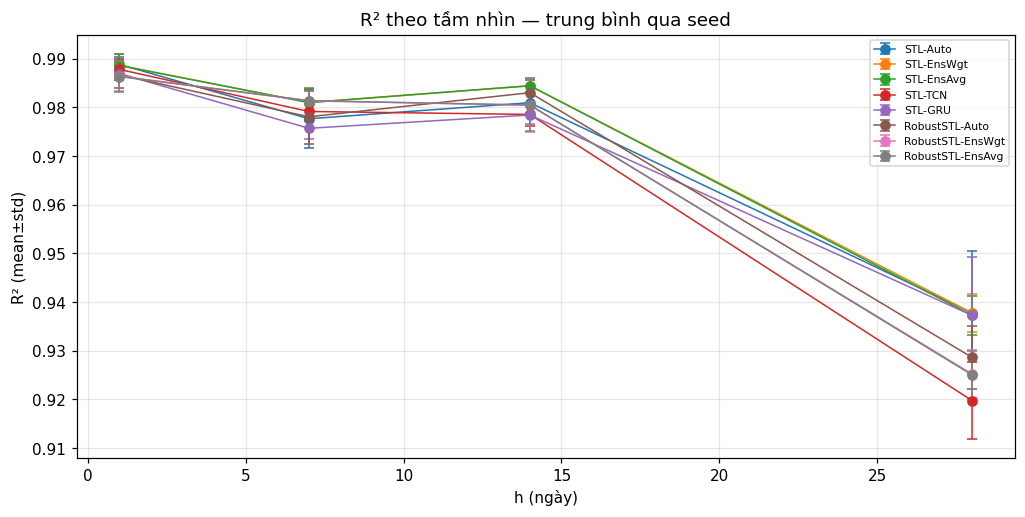

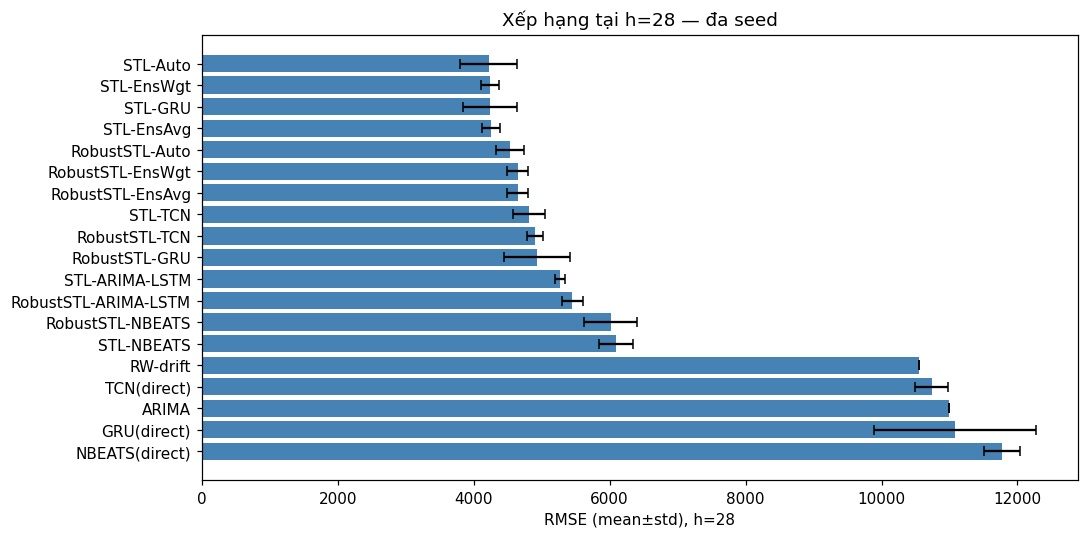

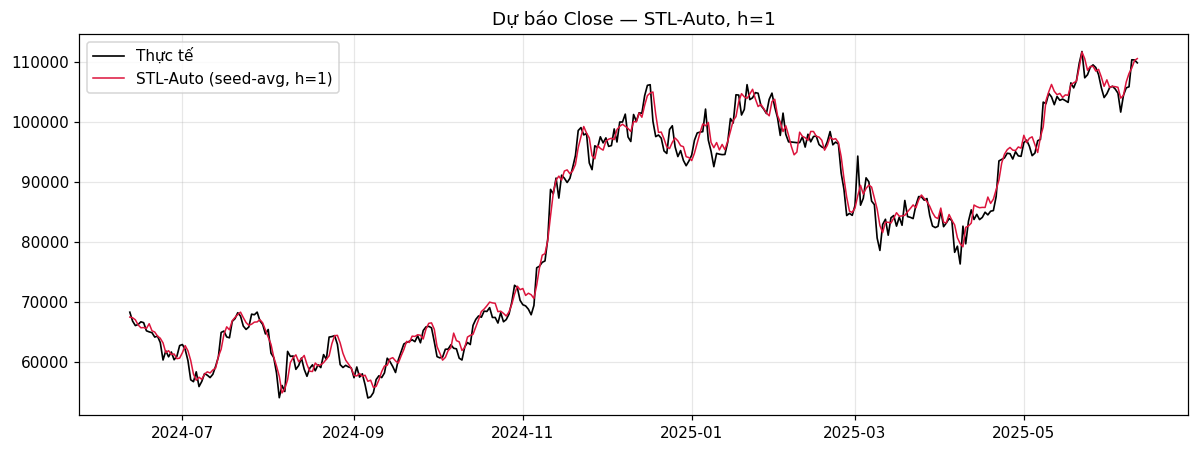

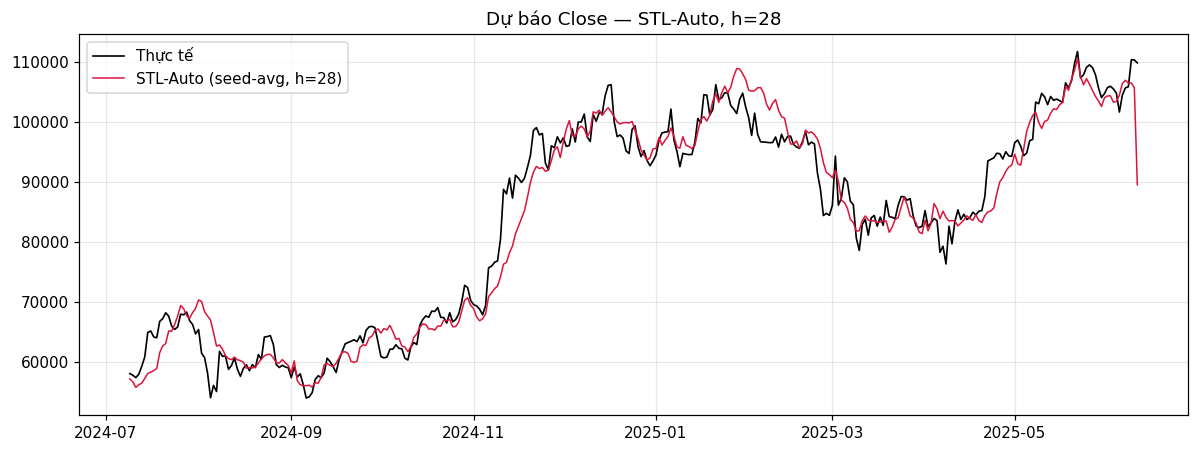

Mô hình tốt nhất (RMSE_mean trung bình các h): STL-Auto
Tất cả kết quả đã lưu tại /content/drive/MyDrive/NCS/Hoa/paper14/3-results_v4/


In [16]:
piv_m=agg.pivot_table(index='Model',columns='h',values='R2_mean')
piv_s=agg.pivot_table(index='Model',columns='h',values='R2_std')
order=list(agg.sort_values('RMSE_mean').Model.unique())
# R2 mean theo h (top mô hình)
top=order[:8]
plt.figure(figsize=(11,5))
for name in top:
    plt.errorbar(HZ,[agg[(agg.Model==name)&(agg.h==h)].R2_mean.values[0] for h in HZ],
                 yerr=[agg[(agg.Model==name)&(agg.h==h)].R2_std.values[0] for h in HZ],marker='o',capsize=3,label=name,lw=1)
plt.xlabel('h (ngày)');plt.ylabel('R² (mean±std)');plt.title('R² theo tầm nhìn — trung bình qua seed');plt.grid(alpha=.3);plt.legend(fontsize=7)
plt.savefig(os.path.join(CONFIG['OUT_DIR'],'R2_mean_std.png'),bbox_inches='tight');plt.show()

# RMSE mean±std tại h lớn nhất
hh=max(HZ); sub=agg[agg.h==hh].sort_values('RMSE_mean')
plt.figure(figsize=(10,5))
plt.barh(sub.Model[::-1],sub.RMSE_mean[::-1],xerr=sub.RMSE_std[::-1],capsize=3,color='steelblue')
plt.xlabel(f'RMSE (mean±std), h={hh}');plt.title(f'Xếp hạng tại h={hh} — đa seed');plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUT_DIR'],f'rank_h{hh}_meanstd.png'),bbox_inches='tight');plt.show()

# dự báo seed-averaged của mô hình tốt nhất
bestm=min(AVG,key=lambda m:np.mean([AVGM[m][h]['RMSE'] for h in HZ]))
for h_show in [1,hh]:
    a=AVG[bestm][h_show];t=df.index[a['idx']]
    plt.figure(figsize=(13,4.5));plt.plot(t,a['y_true'],'k',lw=1.1,label='Thực tế')
    plt.plot(t,a['y_pred'],'crimson',lw=1,label=f'{bestm} (seed-avg, h={h_show})')
    plt.title(f'Dự báo {CONFIG["TARGET"]} — {bestm}, h={h_show}');plt.legend();plt.grid(alpha=.3)
    plt.savefig(os.path.join(CONFIG['OUT_DIR'],f'dubao_{bestm}_h{h_show}.png'),bbox_inches='tight');plt.show()
print('Mô hình tốt nhất (RMSE_mean trung bình các h):',bestm)
print('Tất cả kết quả đã lưu tại',CONFIG['OUT_DIR'])

## 13. Kết luận
- **Direct multi-horizon** loại bỏ hiện tượng nổ ở h=28 (R² h=28 của DEC-⟨arch⟩ ~0.9 thay vì 0.2–0.5).
- **Đa seed** cho **mean±std** + **Wilcoxon/t-test** + **DM/MCS trên dự báo trung bình-qua-seed** ⇒ kết
  luận vững, đạt chuẩn công bố.
- Chọn mô hình cuối theo **MCS** (đa số tầm nhìn) và **DM** (thắng baseline có ý nghĩa); báo cáo kèm
  **độ lệch chuẩn** để chứng minh tính ổn định.

**Tệp xuất:** `aggregate_mean_std.csv`, `{RMSE,MAPE,R2}_mean_matrix.csv`, `seed_averaged_metrics.csv`,
`DM_seedavg.csv`, `MCS_h*.csv`, `wilcoxon_seed.csv`, `metrics_seed*.csv`, và các hình PNG.

**Thời gian:** với **10 seed**, 3 kiến trúc, 2 phân rã, EPOCHS=100 ⇒ ≈ **1.5–3 giờ trên GPU** (gấp đôi
5 seed). Kết quả từng seed được lưu ngay nên có thể theo dõi/khôi phục. Giảm `SEEDS`/`DEEP_MODELS`/`EPOCHS`
hoặc bật `QUICK_MODE` để thử nhanh.
